In [101]:
####Basic Library and dataset calling
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

####Time Series specific libraries
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import coint

In [27]:
####Comverting the data into dataframe, pandas based
data = pd.read_csv(r'/Users/kanishka/Documents/IAQS/Semester 4/SRM4/PAML_Project/portfolio_data9.csv')

In [28]:
###Handling missing values
data.fillna(method='ffill',inplace=True)
####The ffill method is best for time series data as it helps to perform a forward fill. Normally, if value is
####missing, it is because data did not get recorded at that point of time. So just updating it with prior value. 

data.head()

/var/folders/bn/nkp9g7z15pz27pvl9rfd9s8w0000gn/T/ipykernel_76634/2297764157.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill',inplace=True)


,Date,Tech_Index,Crypto_Index
0,2018-01-01,98.435105,49.914987
1,2018-01-02,97.651022,49.902245
2,2018-01-03,97.260020,49.881356
3,2018-01-04,97.094354,49.891945
4,2018-01-05,97.005973,49.886355


In [48]:
####Converting the rows ,i.e., index to proper time stamp
#data.index = pd.to_datetime(data.index)
###As just two columns are there, we can work with data.index which is usual in time series data. 

###Seperating the data between Tech Index and Crypto Index
data_Tech = data.drop('Crypto_Index',axis=1)
data_Crypto = data.drop('Tech_Index',axis=1)


In [49]:
data_Tech.head()

,Date,Tech_Index
0,2018-01-01,98.435105
1,2018-01-02,97.651022
2,2018-01-03,97.260020
3,2018-01-04,97.094354
4,2018-01-05,97.005973


In [50]:
data_Crypto.head()

,Date,Crypto_Index
0,2018-01-01,49.914987
1,2018-01-02,49.902245
2,2018-01-03,49.881356
3,2018-01-04,49.891945
4,2018-01-05,49.886355


****Stationarity Analysis****

In [51]:
####Augmented Dickey Fuller Test

result_Tech = adfuller(data_Tech['Tech_Index'])
result_Crypto = adfuller(data_Crypto['Crypto_Index'])

results_ut_test = pd.DataFrame({
    'Test Statistic' : [result_Tech[0],result_Crypto[0]],
    'P-Value' : [result_Tech[1],result_Crypto[1]]},index=['Tech','Crypto'])

In [52]:
####H0 : Unit Root exists in the characteristic equation of the time series.
####H1 : UNit root does not exist in the characteristic equation of the time series. 

#### Since palue > .05 for both Tech and Crypto, we have insufficient evidence to reject H0. Thus, both Tech Index and Crypto Index belong to 
#### non stationary time series. 

****Data Transformation****

In [53]:
data_Tech['log_ret_tech'] = np.log((data_Tech['Tech_Index'])/(data_Tech['Tech_Index'].shift(1)))
data_Crypto['log_ret_crypto'] = np.log((data_Crypto['Crypto_Index'])/(data_Crypto['Crypto_Index'].shift(1)))
ln_ret_tech = data_Tech.dropna().drop('Tech_Index',axis=1)
ln_ret_crytpo = data_Crypto.dropna().drop('Crypto_Index',axis=1)



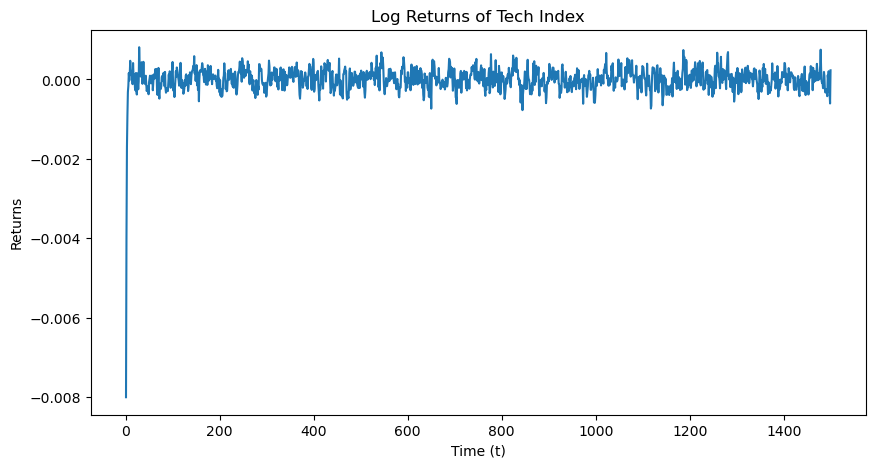

In [54]:
####Plotting the time series using scatter plot_Tech
plt.figure(figsize=(10,5))
plt.plot(ln_ret_tech['log_ret_tech'])
plt.title('Log Returns of Tech Index')
plt.xlabel('Time (t)')
plt.ylabel('Returns')
plt.show()


###Data does not seem to have any trend and on visual metric, it doers seem to be stationary. 
###However, there is a spike at start in Tech_Index_Returns which needs investigation

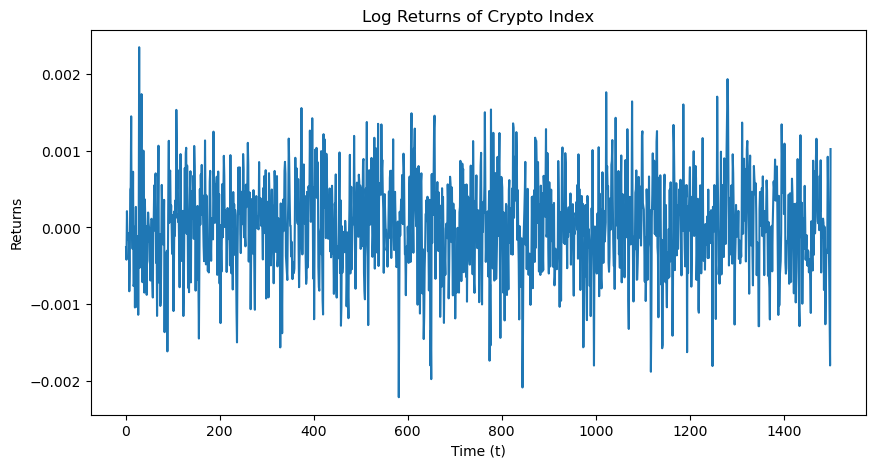

In [57]:
####Plotting the time series using scatter plot_CRYPTO
plt.figure(figsize=(10,5))
plt.plot(ln_ret_crytpo['log_ret_crypto'])
plt.title('Log Returns of Crypto Index')
plt.xlabel('Time (t)')
plt.ylabel('Returns')
plt.show()


###Data does not seem to have any trend and on visual metric, it doers seem to be stationary. 

In [62]:
result_Tech_ln_ret = adfuller(ln_ret_crytpo['log_ret_crypto'])
result_Crypto_ln_ret = adfuller(ln_ret_crytpo['log_ret_crypto'])

results_ut_test_ln_ret = pd.DataFrame({
    'Test Statistic' : [result_Tech_ln_ret[0],result_Crypto_ln_ret[0]],
    'P-Value' : [result_Tech_ln_ret[1],result_Crypto_ln_ret[1]]},index=['Tech','Crypto'])
results_ut_test_ln_ret

####The Test Statsitic Values are very negitive asnd pvalue is 0. Thus, we have suffienct evidence to reject null hypothesis that unit root is present in any of the 
####Characteristic equations of the time series and hence, both the log returns process are stationary. 

,Test Statistic,P-Value
Tech,-24.014132,0.0
Crypto,-24.014132,0.0


****Time Series Fitting and Box Jerkins Forecasts****

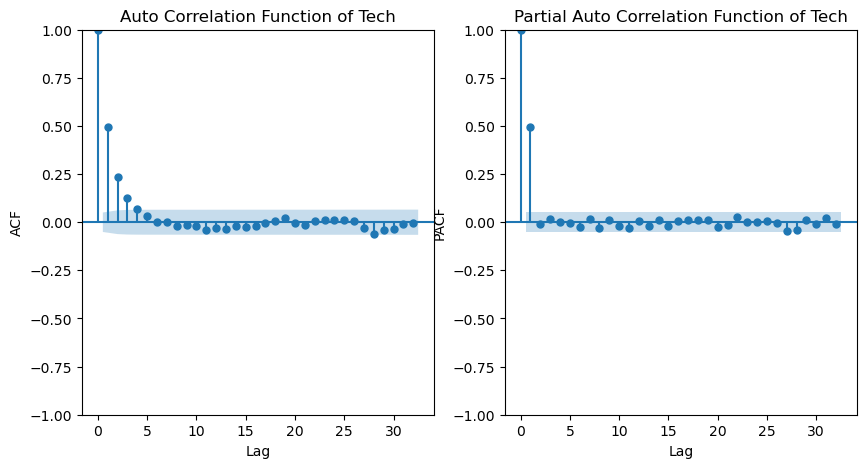

In [75]:
####Log Retirns for Tech Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_acf(ln_ret_tech['log_ret_tech'], ax=axes[0])
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].set_title('Auto Correlation Function of Tech')

plot_pacf(ln_ret_tech['log_ret_tech'], ax=axes[1])
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('PACF')
axes[1].set_title('Partial Auto Correlation Function of Tech')
plt.show()


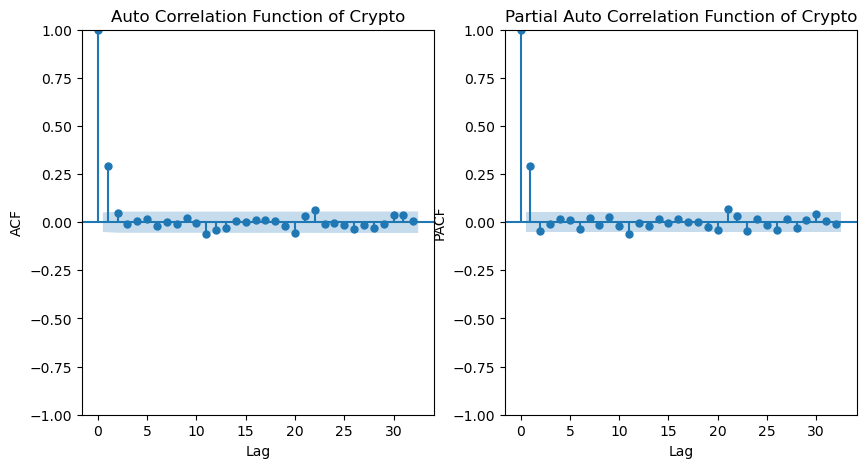

In [77]:
####Log Retirns for Tech Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_acf(ln_ret_crytpo['log_ret_crypto'], ax=axes[0])
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].set_title('Auto Correlation Function of Crypto')

plot_pacf(ln_ret_crytpo['log_ret_crypto'], ax=axes[1])
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('PACF')
axes[1].set_title('Partial Auto Correlation Function of Crypto')
plt.show()

In [ ]:
####For Tech, the ACF cuts off post lag 5 and PACF cuts off post lag 2. Thus, this is an ARMA(2,5) process. 
####For Crypto, the ACF cuts off post lag 2 and PACF cuts off post lag 2. Thus, this is an ARMA(2,2) process. 
####This is based on Tentative Identification of the process. 

In [78]:
####Fitting the model for Tech 

model_tech = ARIMA(ln_ret_tech['log_ret_tech'],order=(2,0,5))
results_tech = model_tech.fit()
print(results_tech.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           log_ret_tech   No. Observations:                 1499
Model:                 ARIMA(2, 0, 5)   Log Likelihood               10197.154
Date:                Sat, 21 Mar 2026   AIC                         -20376.308
Time:                        00:55:01   BIC                         -20328.495
Sample:                             0   HQIC                        -20358.495
                               - 1499                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.123e-06   1.89e-05      0.113      0.910   -3.48e-05    3.91e-05
ar.L1          0.1536   4.01e-10   3.83e+08      0.000       0.154       0.154
ar.L2          0.0090   7.83e-10   1.15e+07      0.0

In [81]:
####Fitting the model for Tech 

model_crypto = ARIMA(ln_ret_crytpo['log_ret_crypto'],order=(2,0,2))
results_crypto = model_crypto.fit()
print(results_crypto.summary())

                               SARIMAX Results                                
Dep. Variable:         log_ret_crypto   No. Observations:                 1499
Model:                 ARIMA(2, 0, 2)   Log Likelihood                9044.277
Date:                Sat, 21 Mar 2026   AIC                         -18076.554
Time:                        00:57:03   BIC                         -18044.679
Sample:                             0   HQIC                        -18064.679
                               - 1499                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.938e-05   2.02e-05      0.958      0.338   -2.03e-05     5.9e-05
ar.L1          0.0499      0.013      3.853      0.000       0.025       0.075
ar.L2         -0.0488      0.084     -0.580      0.5

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


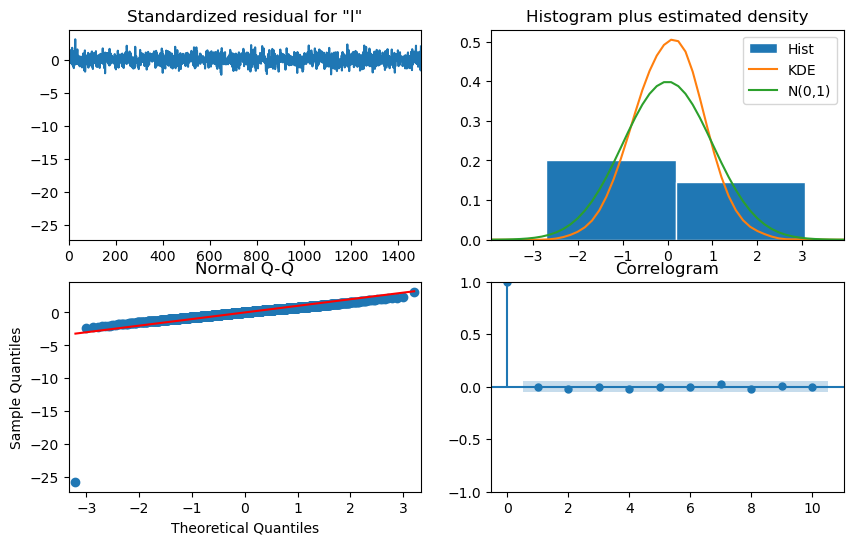

In [83]:
####Diagnostic Diagnostics_Tech
results_tech.plot_diagnostics(figsize=(10,6))
plt.show()

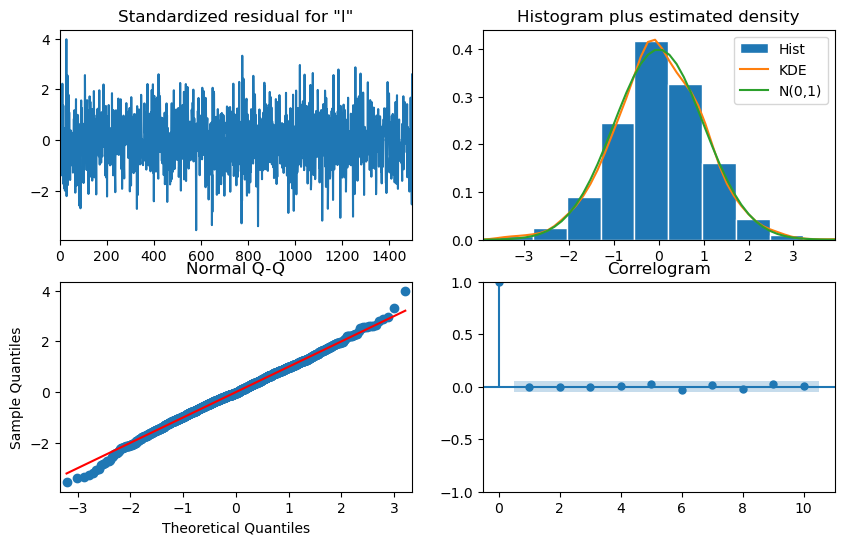

In [88]:
####Diagnostic Diagnostics_Tech
results_crypto.plot_diagnostics(figsize=(10,6))
plt.show()

In [131]:
aic_tech = results_tech.aic
aic_crypto = results_crypto.aic
print(f"AIC of Log Ret of Tech : {aic_tech} , AIC of Log Returns of Crypto : {aic_crypto}")

AIC of Log Ret of Tech : -20376.307819590253 , AIC of Log Returns of Crypto : -18076.554214783282


In [ ]:
####Both the AIC values are very negitive. Thus, models are excellent fit and residuals are minimal. 
####Tech model fits slughtly better. 

In [95]:
pmtau_test_tech = acorr_ljungbox(results_tech.resid,lags=20,return_df=True)
pmtau_test_tech

,lb_stat,lb_pvalue
1,3.867757e-09,0.999950
2,6.977713e-01,0.705474
3,7.150353e-01,0.869662
4,1.496121e+00,0.827328
5,1.497405e+00,0.913369
6,1.530571e+00,0.957438
7,2.244984e+00,0.945047
8,3.018971e+00,0.933161
9,3.060058e+00,0.961866
10,3.061157e+00,0.979948


In [96]:
pmtau_test_crypto = acorr_ljungbox(results_crypto.resid,lags=20,return_df=True)
pmtau_test_crypto

,lb_stat,lb_pvalue
1,3.194199e-09,0.999955
2,1.062756e-04,0.999947
3,1.933905e-03,0.999977
4,1.609465e-02,0.999968
5,1.010339e+00,0.961728
6,2.586426e+00,0.858673
7,2.950518e+00,0.889542
8,3.560261e+00,0.894463
9,4.555941e+00,0.871175
10,4.705002e+00,0.909993


In [ ]:
####The output of pvalue of portmantau test is very large until 20 lags. Thus, indicates no autocorrelation between residuals, for both tech and crypto, and thus, 
###this validates the model fit even further. 

****Co Linearity Check****

In [112]:
####H0: The log returns of the two indexs are not co integrated.
####H1: The log returns of the two indexs are co integrated. 

co_int_check = coint(ln_ret_tech['log_ret_tech'],ln_ret_crytpo['log_ret_crypto'])
co_integrated_check = pd.DataFrame({
     'Metric' : ['Test Statistic','p_value'],
     'value' : [co_int_check[0],co_int_check[1]]
})
co_integrated_check

###The p-value is 0 and test statistic is also very large on negitive side. Thus, We have sufficient evidence to reject H0. Hence, The two indexes are co integrated. 

,Metric,value
0,Test Statistic,-36.020372
1,p_value,0.000000


****Forecasts****

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


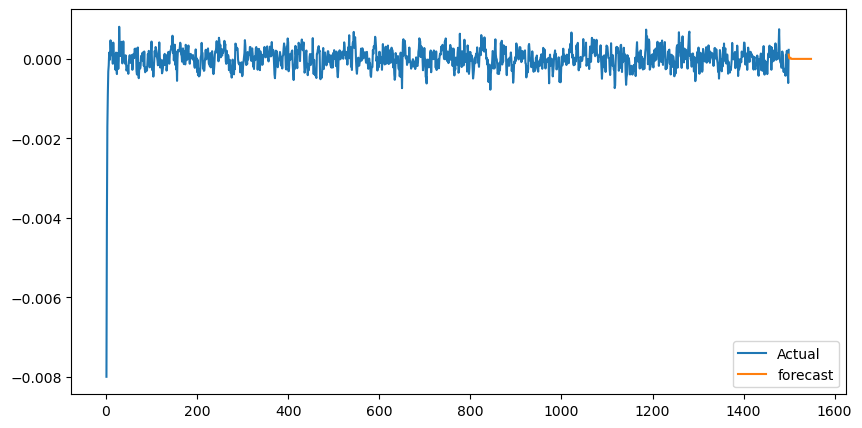

In [99]:
####Forecast for Tech 

forecast_tech = results_tech.forecast(steps=50)

plt.figure(figsize=(10,5))
plt.plot(ln_ret_tech['log_ret_tech'],label = 'Actual')
plt.plot(forecast_tech,label = 'forecast')
plt.legend()
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


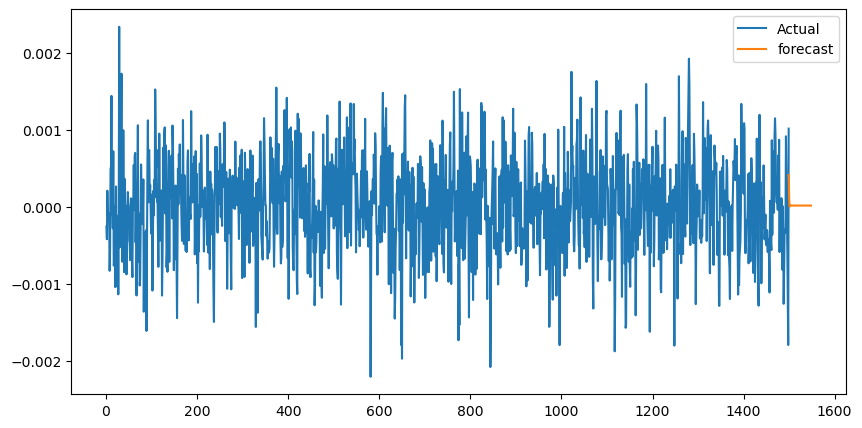

In [113]:
####Forecast for Crypto

forecast_crypto = results_crypto.forecast(steps=50)

plt.figure(figsize=(10,5))
plt.plot(ln_ret_crytpo['log_ret_crypto'],label = 'Actual')
plt.plot(forecast_crypto,label = 'forecast')
plt.legend()
plt.show()


****Exporting Residuals for EVT Task****

In [125]:
tech_resid = pd.DataFrame(results_tech.resid,columns=['Tech_resid'])
tech_resid

tech_resid['tech_losses'] = -tech_resid
tech_resid

crypto_resid = pd.DataFrame(results_crypto.resid,columns=['crypto_resid'])
crypto_resid

crypto_resid['crytpo_losses'] = -crypto_resid
crypto_resid

,crypto_resid,crytpo_losses
1,-0.000275,0.000275
2,-0.000357,0.000357
3,0.000315,-0.000315
4,-0.000213,0.000213
5,-0.000047,0.000047
...,...,...
1495,-0.000145,0.000145
1496,-0.000503,0.000503
1497,-0.001036,0.001036
1498,-0.001470,0.001470


In [132]:
tech_resid.to_csv(r'/Users/kanishka/Documents/IAQS/Semester 4/SRM4/PAML_Project/residuals_tech.csv',index=False)
crypto_resid.to_csv(r'/Users/kanishka/Documents/IAQS/Semester 4/SRM4/PAML_Project/residuals_crypto.csv',index=False)